In [1]:
# ==========================================================
# CUSTOMER CHURN ANALYSIS PROJECT
# FULL PROFESSIONAL PYTHON WORKFLOW
# Author : Mansour meshwady
#===========================================================



#===========================================================
# 1. Import Libraries
#===========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#===========================================================
# 2. Load Dataset
#===========================================================
df=pd.read_csv(r"C:\Users\mansour\Downloads\dataset\Telco Customer Churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head)

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [3]:
#===========================================================
# 3. Basic Exploration
#===========================================================
# Shape
print("\n Data Shape")
print(df.shape)
# Info
print("\n Data Info")
print(df.info())
# Statistical summary
print("\n Data Description")
print(df.describe())
# Check missing values in every column.
print("\n Null Values")
print(df.isnull().sum())
# Check dublicated values in every column.
print("\n Duplicated Values")
print(df.duplicated())


 Data Shape
(7043, 21)

 Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

In [4]:
#===========================================================
#4.Data Cleaning
#===========================================================
# Convert TotalCharges  and tenure to numeric.
df['TotalCharges'] = pd.to_numeric(df["TotalCharges"],errors='coerce')
df['tenure'] = pd.to_numeric(df["tenure"],errors='coerce')
# Fill missing values using mean.
df['TotalCharges'].fillna(df["TotalCharges"].mean(), inplace=True )
# Remove duplicate rows.
df.drop_duplicates(inplace=True)

# Recheck missing values after cleaning.
print("Missing Values after cleaning \n")
print(df.isnull().sum())

print(df.info())

Missing Values after cleaning 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   Phone

C:\Users\mansour\AppData\Local\Temp\ipykernel_10616\999139372.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df["TotalCharges"].mean(), inplace=True )


In [5]:
#===========================================================
#5. Feature Engineering
#===========================================================

# Create tenure groups.
df['TenureGroup'] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=['0-1 Year','1-2 Years','2-3 Years','3-4 Years']
)

# Create charge categories.
df['ChargeCategory'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0,35,70,120],
    labels=['Low','Medium','High']
)


print(df[['tenure','TenureGroup']].head())


   tenure TenureGroup
0       1    0-1 Year
1      34   2-3 Years
2       2    0-1 Year
3      45   2-3 Years
4       2    0-1 Year


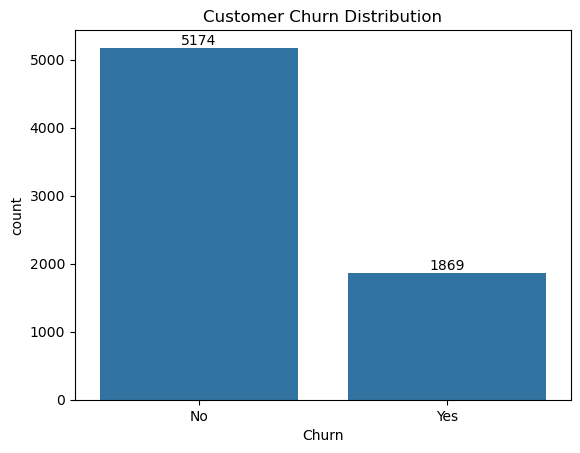


 Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [6]:
# ==========================================================
# 6. Churn Distribution Analysis
# ==========================================================

ax=sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Percentage distribution.
print("\n Churn Percentage:")
print(
   round(
    df['Churn'].value_counts(normalize=True)*100,2
))


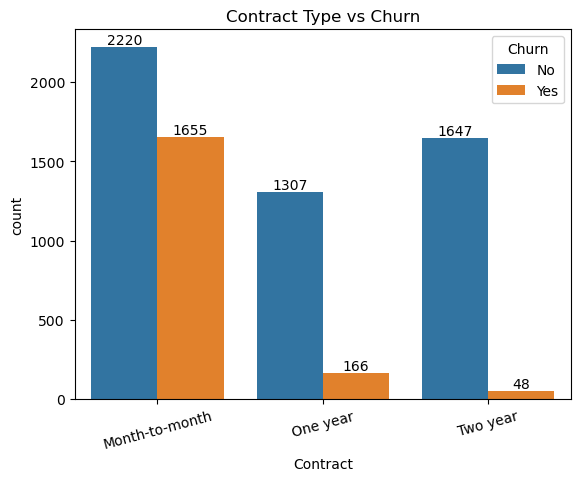

In [7]:
# ==========================================================
# 7. CONTRACT TYPE ANALYSIS
# ==========================================================

ax = sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.show()


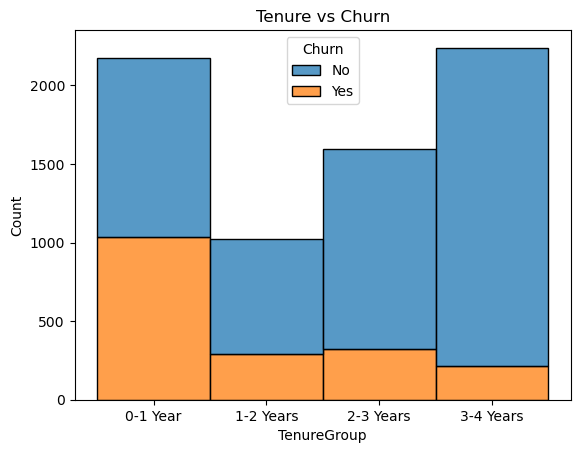

In [8]:
# ==========================================================
# 8. TENURE ANALYSIS
# ==========================================================

sns.histplot(
    data=df,
    x='TenureGroup',
    hue='Churn',
    multiple='stack'
)

plt.title("Tenure vs Churn")

plt.show()


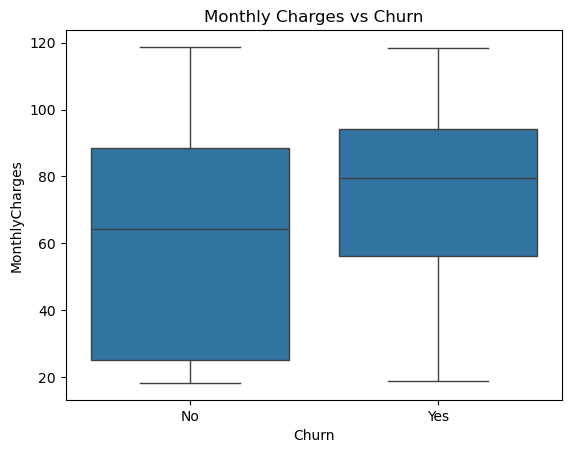

In [9]:
# ==========================================================
# 9. MONTHLY CHARGES ANALYSIS
# ==========================================================

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

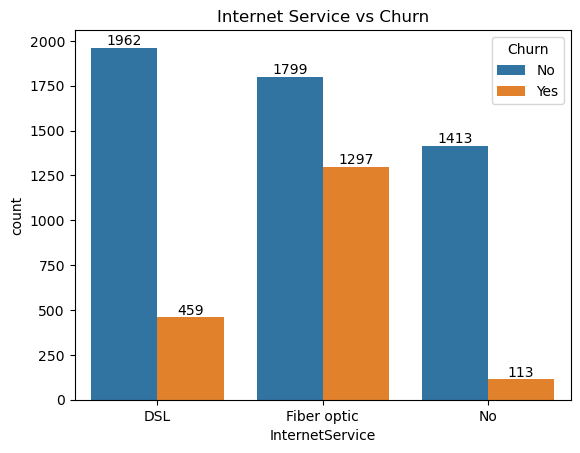

In [10]:
# ==========================================================
# 10. INTERNET SERVICE ANALYSIS
# ==========================================================

ax = sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

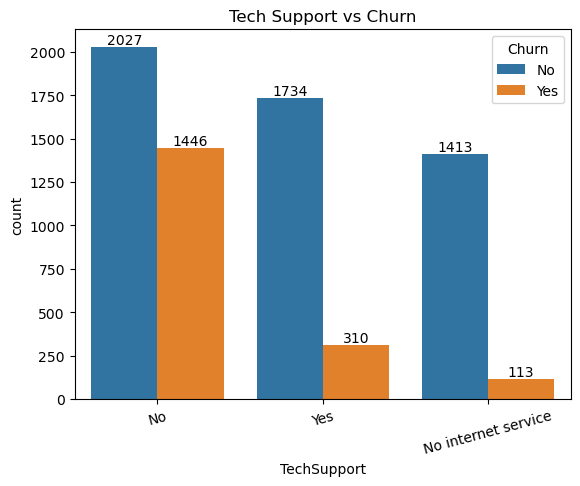

In [11]:
# ==========================================================
# 11. TECH SUPPORT ANALYSIS
# ==========================================================

ax = sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)

plt.title("Tech Support vs Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.show()

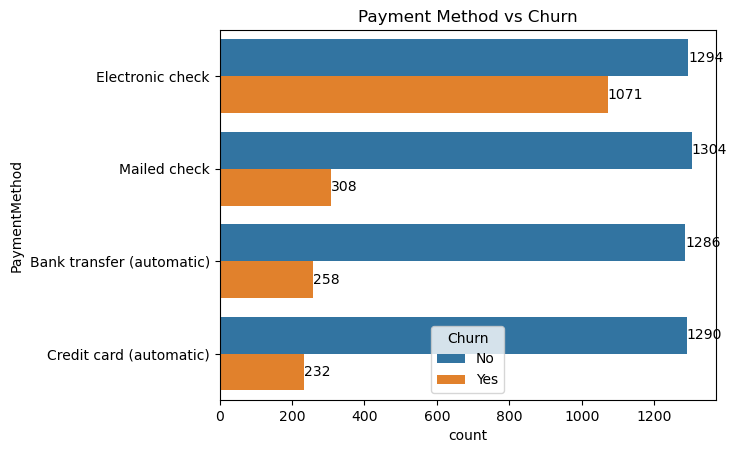

In [12]:
# ==========================================================
# 12. PAYMENT METHOD ANALYSIS
# ==========================================================

ax = sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title("Payment Method vs Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


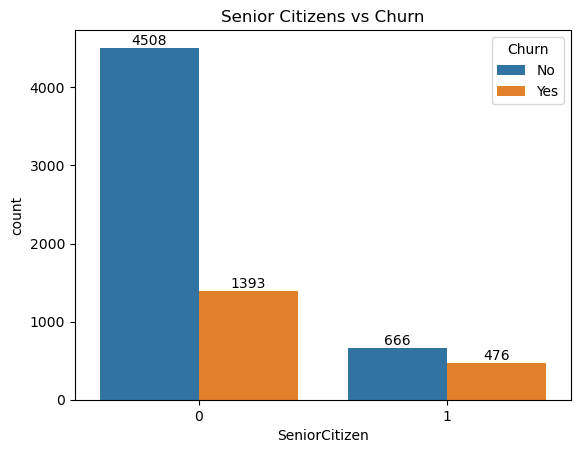

In [18]:
# ==========================================================
# 13. SENIOR CITIZEN ANALYSIS
# ==========================================================

ax = sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title("Senior Citizens vs Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [14]:
# ==========================================================
# 14. HIGH-RISK CUSTOMER SEGMENT
# ==========================================================

high_risk = df[
    (df['Contract'] == 'Month-to-month')
    &
    (df['tenure'] < 12)
    &
    (df['MonthlyCharges'] > 70)
]


print("\nHigh Risk Customers:")
print(high_risk.head())


print("\nNumber of High Risk Customers:")
print(len(high_risk))


High Risk Customers:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
4   9237-HQITU  Female              0      No         No       2          Yes   
5   9305-CDSKC  Female              0      No         No       8          Yes   
31  4929-XIHVW    Male              1     Yes         No       2          Yes   
39  8168-UQWWF  Female              0      No         No      11          Yes   
47  7760-OYPDY  Female              0      No         No       2          Yes   

   MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
4             No     Fiber optic             No  ...          No   
5            Yes     Fiber optic             No  ...         Yes   
31            No     Fiber optic             No  ...         Yes   
39           Yes     Fiber optic             No  ...         Yes   
47            No     Fiber optic             No  ...         Yes   

   StreamingMovies        Contract PaperlessBilling  \
4               No  Month-t

In [15]:
# ==========================================================
# 15. CHURN RATE BY TENURE GROUP
# ==========================================================

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100


print("\nChurn Rate by Tenure Group:")
print(round(tenure_churn,2))



Churn Rate by Tenure Group:
Churn           No    Yes
TenureGroup              
0-1 Year     52.32  47.68
1-2 Years    71.29  28.71
2-3 Years    79.61  20.39
3-4 Years    90.49   9.51


In [16]:
# ==========================================================
# 16. FINAL BUSINESS SUMMARY
# ==========================================================

print("""

==================================================
FINAL BUSINESS INSIGHTS
==================================================

1. Month-to-month contracts have the highest churn.

2. New customers are more likely to leave.

3. High monthly charges increase churn probability.

4. Fiber optic customers show elevated churn rates.

5. Lack of technical support increases churn.

6. Electronic check users churn more often.

7. Long-term customers are more loyal.

==================================================
FINAL BUSINESS RECOMMENDATIONS
==================================================

1. Promote long-term contracts.

2. Improve onboarding experience.

3. Review pricing strategies.

4. Improve technical support services.

5. Investigate fiber internet issues.

6. Encourage automatic payment methods.

7. Create retention campaigns
   for high-risk customers.

==================================================

""")



FINAL BUSINESS INSIGHTS

1. Month-to-month contracts have the highest churn.

2. New customers are more likely to leave.

3. High monthly charges increase churn probability.

4. Fiber optic customers show elevated churn rates.

5. Lack of technical support increases churn.

6. Electronic check users churn more often.

7. Long-term customers are more loyal.

FINAL BUSINESS RECOMMENDATIONS

1. Promote long-term contracts.

2. Improve onboarding experience.

3. Review pricing strategies.

4. Improve technical support services.

5. Investigate fiber internet issues.

6. Encourage automatic payment methods.

7. Create retention campaigns
   for high-risk customers.



